# Week 06: IPO & distribution shapes — **self-paced**

**Course:** MATH7810 Python for Data Science (AY2026/27)  
Work through the tasks **in order**. The instructor will **walk around**. Ask if you are stuck after the “If you are stuck” steps.

**This notebook:** Binomial shape, standardizing $Z$, continuity correction, Normal quantile.  


## How to work today

| Step | What you do |
|------|----------------|
| 1 | Read the **task**. |
| 2 | Complete or use the **IPO** comments. |
| 3 | **`Cmd+I` / `Ctrl+I`** → implement comments → **Keep**. |
| 4 | **Read** the code → **Shift+Enter**. |
| 5 | Type the short note and **run** it. |

**If stuck:** Setup ran? Process filled? Then ask — bring what you tried.

## A. IPO reminder

Same habit as Week 5. **Input → Process → Output. AI drafts; **you** verify. The same prompt can differ across runs.


## Setup — run this **first**

**Done when:** the cell prints `Ready` with no error.


In [1]:
# Setup — run this cell first
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm, expon  # short names for Binomial, Normal, Exponential

rng = np.random.default_rng(42)  # reproducible draws for the sim tasks
print("Ready. numpy", np.__version__)  # prints which NumPy you have; __version__ is the name of that version label


Ready. numpy 2.5.2


## Task 1 — Binomial shape vs \(p\)

**Question:** How does the shape of a Binomial distribution differ for different values of \(p\)?

Keep **\(n = 10\)** fixed. Only **\(p\)** changes: **0.2**, **0.5**, **0.9**.

Fill **Process** and **Output**, then Inline Chat.

**Done when:** three bar charts in a row + 1–2 sentences on skewness.

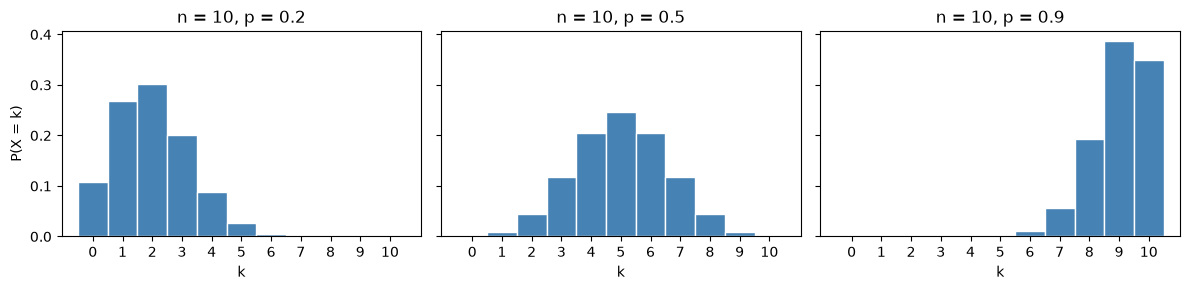

In [2]:
# Task 1 — Binomial PMFs in a row (fixed n, three p)
# --- AI prompt: Input -> Process -> Output ---
# Input: scipy.stats.binom, numpy (np.arange) and matplotlib.pyplot — all already imported.
# Process: fix n = 10; for each p in [0.2, 0.5, 0.9] evaluate the PMF on k = 0..10 with
#   binom.pmf(k, n, p) and draw it as a bar chart; put the three charts side by side
#   (sharey=True) so the shapes can be compared at a glance.
# Output: one figure with three panels (x = k, y = P(X = k)), each titled with its p.
# --- End prompt ---
# --- generated / your code below ---
ks = np.arange(0, 11)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, p in zip(axes, [0.2, 0.5, 0.9]):
    ax.bar(ks, binom.pmf(ks, 10, p), width=1.0, color="steelblue", edgecolor="white")
    ax.set_title(f"n = 10, p = {p}")
    ax.set_xlabel("k")
    ax.set_xticks(ks)
axes[0].set_ylabel("P(X = k)")
plt.tight_layout()
plt.show()


**Check:** Does the output make sense? Why? Type in the next cell, then **run** it.


In [3]:
# Task 1 — write BETWEEN the triple quotes, then RUN
task1_skew = """
# Skewness (p = 0.2 / 0.5 / 0.9):
# p = 0.2: np = 2, the peak sits at the left end and a long tail runs to the right -> right-skewed.
# p = 0.5: symmetric about k = 5 — the two halves mirror each other.
# p = 0.9: np = 9, the peak sits at the right end and the tail runs to the left -> left-skewed.
# So the further p is from 0.5, the stronger the skew; at p = 0.5 the Binomial is symmetric.
"""
print(task1_skew)



# Skewness (p = 0.2 / 0.5 / 0.9):
# p = 0.2: np = 2, the peak sits at the left end and a long tail runs to the right -> right-skewed.
# p = 0.5: symmetric about k = 5 — the two halves mirror each other.
# p = 0.9: np = 9, the peak sits at the right end and the tail runs to the left -> left-skewed.
# So the further p is from 0.5, the stronger the skew; at p = 0.5 the Binomial is symmetric.



## Task 2 — Standardizing does **not** create a Normal

**Question:** If we rescale a variable so it has mean 0 and variance 1, is the result always Normal?

Lecture: $Z = (X-\mu)/\sigma$ has **mean 0** and **variance 1**, but is Normal **only if** $X$ is Normal.

Let $X$ be **Exponential** (scale $= 2$). Draw 10,000 values, form $Z$, print mean/var of $Z$, histogram $X$ and $Z$, overlay $N(0,1)$ on $Z$.

Fill **Process** and **Output**, then Inline Chat.

**Done when:** mean of $Z$ is about $0$, variance about $1$, but $Z$ still looks **skewed**.


mean(Z) = -0.0225   var(Z) = 0.9494
sample mean/sd of X: 1.9550 / 1.9488
skew(Z) = 1.919   (Exponential skewness = 2, Normal skewness = 0)


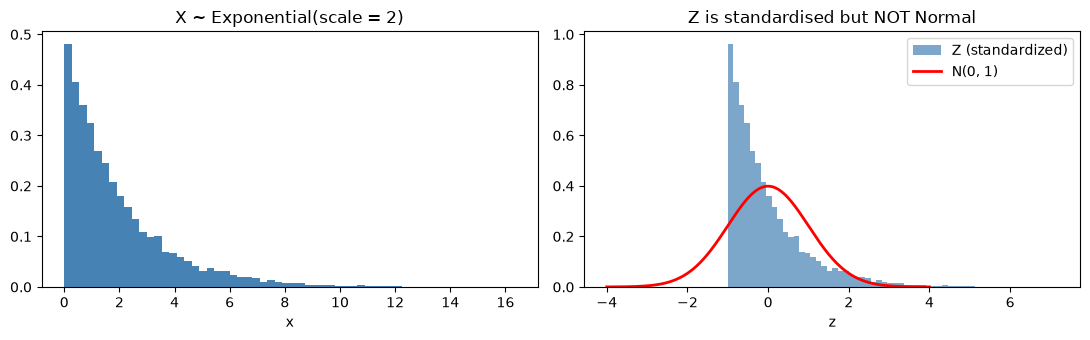

In [4]:
# Task 2 — Standardize a non-Normal X
# --- AI prompt: Input -> Process -> Output ---
# Input: numpy, matplotlib.pyplot, rng, scipy.stats.expon, scipy.stats.norm (and scipy.stats.skew
#   for the shape evidence) — all available.
# Process: draw 10,000 values from Exponential(scale=2) (mean = sd = 2); form Z = (X - 2) / 2;
#   print mean and variance of Z; histogram X and Z side by side and overlay N(0, 1) on Z.
# Output: printed mean/var (about 0 and 1) + a 1x2 figure where Z is clearly still skewed.
# --- End prompt ---
# --- generated / your code below ---
from scipy.stats import skew

X = expon.rvs(scale=2, size=10_000, random_state=42)
Z = (X - 2.0) / 2.0                      # Exponential(scale=2): mean = sd = 2

print(f"mean(Z) = {Z.mean():.4f}   var(Z) = {Z.var():.4f}")
print(f"sample mean/sd of X: {X.mean():.4f} / {X.std(ddof=1):.4f}")
print(f"skew(Z) = {skew(Z):.3f}   (Exponential skewness = 2, Normal skewness = 0)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(X, bins=60, density=True, color="steelblue")
axes[0].set_title("X ~ Exponential(scale = 2)")
axes[0].set_xlabel("x")

axes[1].hist(Z, bins=60, density=True, color="steelblue", alpha=0.7, label="Z (standardized)")
xs = np.linspace(-4, 4, 400)
axes[1].plot(xs, norm.pdf(xs), "r-", lw=2, label="N(0, 1)")
axes[1].set_title("Z is standardised but NOT Normal")
axes[1].set_xlabel("z")
axes[1].legend()
plt.tight_layout()
plt.show()


**Check:** mean/var of \(Z\) vs **shape** of \(Z\). Type 1–2 sentences in the next cell, then run it.


In [5]:
# Task 2 — write BETWEEN the triple quotes, then RUN
task5_z = """
# Mean/var of Z vs shape of Z:
# The mean of Z is about 0 and the variance about 1, so the rescaling did exactly what it promises.
# But the histogram of Z is still strongly right-skewed and the N(0, 1) curve does not fit it
# (sample skewness of Z is about 2, the same as the Exponential itself).
# Reason: standardising only moves the centre and rescales the spread. It cannot create Normality —
# Z is Normal only if X is Normal, and here X is Exponential.
"""
print(task5_z)



# Mean/var of Z vs shape of Z:
# The mean of Z is about 0 and the variance about 1, so the rescaling did exactly what it promises.
# But the histogram of Z is still strongly right-skewed and the N(0, 1) curve does not fit it
# (sample skewness of Z is about 2, the same as the Exponential itself).
# Reason: standardising only moves the centre and rescales the spread. It cannot create Normality —
# Z is Normal only if X is Normal, and here X is Exponential.



## Task 3 — Normal approximation and continuity correction

**Question:** A Binomial count is a whole number; a Normal curve is continuous. Why do we need a continuity correction when we approximate Binomial probabilities with a Normal?

Each Binomial bar sits on an integer and has **width 1**. The matching Normal area for that bar is from half a unit below to half a unit above — a **continuity correction**.

**Example**: **$n = 16$**, **$p = 0.5$**, so $np = 8 > 5$ and $n(1-p) = 8 > 5$. Let $X$ be Binomial; let $Y$ be Normal with the same mean $np$ and sd $\sqrt{np(1-p)}$.

1. Plot the Binomial PMF bars and overlay the Normal curve.
2. Print three values of $P(X \le 6)$: 
- exact Binomial; 
- Normal **without** correction ($Y \le 6$); 
- Normal **with** correction ($Y \le 6.5$).

Fill **Process** and **Output**, then Inline Chat.

**Done when:** one plot and three printed probabilities. If it helps, add vertical lines at 6 and 6.5 so the half-unit gap is easy to see.


exact   P(X <= 6)   = 0.22725
Normal  P(Y <= 6)   = 0.15866   (no correction)
Normal  P(Y <= 6.5) = 0.22663   (with +0.5)
|error| no correction = 0.06859   with correction = 0.00062


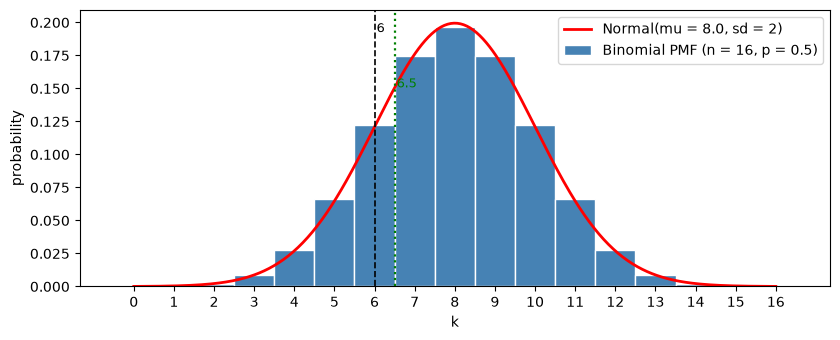

In [6]:
# Task 3 — Normal approx. + continuity correction
# --- AI prompt: Input -> Process -> Output ---
# Input: numpy, matplotlib.pyplot, scipy.stats.binom, scipy.stats.norm — all already imported.
# Process: n = 16, p = 0.5 -> mu = np = 8, sd = sqrt(np(1-p)) = 2; compare three values of
#   P(X <= 6): exact Binomial (binom.cdf), Normal without correction (norm.cdf at 6) and Normal
#   with correction (norm.cdf at 6.5). Plot the Binomial PMF bars of width 1 with the Normal
#   curve on top and mark 6 and 6.5.
# Output: one figure + three printed probabilities (and the two absolute errors).
# --- End prompt ---
# --- generated / your code below ---
n, p = 16, 0.5
mu, sd = n * p, np.sqrt(n * p * (1 - p))

exact = binom.cdf(6, n, p)        # exact Binomial P(X <= 6)
no_cc = norm.cdf(6, mu, sd)       # Normal, NO continuity correction
cc = norm.cdf(6.5, mu, sd)        # Normal, WITH continuity correction (+0.5)

print(f"exact   P(X <= 6)   = {exact:.5f}")
print(f"Normal  P(Y <= 6)   = {no_cc:.5f}   (no correction)")
print(f"Normal  P(Y <= 6.5) = {cc:.5f}   (with +0.5)")
print(f"|error| no correction = {abs(no_cc - exact):.5f}   with correction = {abs(cc - exact):.5f}")

ks = np.arange(0, n + 1)
fig, ax = plt.subplots(figsize=(8.5, 3.5))
ax.bar(ks, binom.pmf(ks, n, p), width=1.0, color="steelblue", edgecolor="white",
       label="Binomial PMF (n = 16, p = 0.5)")
xs = np.linspace(0, n, 400)
ax.plot(xs, norm.pdf(xs, mu, sd), "r-", lw=2, label=f"Normal(mu = {mu}, sd = {sd:.0f})")
ax.axvline(6, color="k", ls="--", lw=1.2)
ax.axvline(6.5, color="green", ls=":", lw=1.6)
ax.text(6.05, ax.get_ylim()[1] * 0.92, "6", fontsize=9)
ax.text(6.55, ax.get_ylim()[1] * 0.72, "6.5", fontsize=9, color="green")
ax.set_xlabel("k")
ax.set_ylabel("probability")
ax.set_xticks(ks)
ax.legend()
plt.tight_layout()
plt.show()


**Check:** which Normal probability is closer to the exact Binomial $P(X \le 6)$? Type in the next cell, then run it.


In [7]:
# Task 3 — write BETWEEN the triple quotes, then RUN
task3_cc = """
# Which Normal value is closer, and why add 0.5:
# The corrected Normal value is much closer to the exact Binomial value; without the correction the
# Normal value is far too small.
# Why 0.5: a Binomial bar sitting on k covers the interval [k - 0.5, k + 0.5] (each bar has width 1),
# so the Normal area that matches P(X <= 6) is the area up to 6.5, not up to 6. The +0.5 is exactly
# half of that bar width.
"""
print(task3_cc)



# Which Normal value is closer, and why add 0.5:
# The corrected Normal value is much closer to the exact Binomial value; without the correction the
# Normal value is far too small.
# Why 0.5: a Binomial bar sitting on k covers the interval [k - 0.5, k + 0.5] (each bar has width 1),
# so the Normal area that matches P(X <= 6) is the area up to 6.5, not up to 6. The +0.5 is exactly
# half of that bar width.



## Task 4 — Normal quantile from a probability

**Question:** In lecture we read a $z$-table *backwards*: given an area, find $z_0$. How do we do that in Python?

Lecture example: find $z_0$ if $P(Z < z_0) = 0.75$ (table: about $0.67$).

`scipy.stats.norm.ppf` is the inverse of `norm.cdf`: given a left-tail probability, it returns the cut-off.

Fill **Process** and **Output**, then Inline Chat.

**Done when:** the printed $z_0$ is close to $0.67$.


In [8]:
# Task 4 — Normal quantile (ppf)
# --- AI prompt: Input -> Process -> Output ---
# Input: scipy.stats.norm — already imported.
# Process: use norm.ppf, the inverse of norm.cdf, to turn a left-tail probability back into a
#   cut-off; ask for P(Z < z0) = 0.75 and also cross-check the two lecture reverse look-ups.
# Output: printed z0 for 0.75 (should be about 0.67) plus ppf(0.95) and ppf(0.99).
# --- End prompt ---
# --- generated / your code below ---
z0 = norm.ppf(0.75)
print(f"z0 with P(Z < z0) = 0.75 : {z0:.5f}  ->  {z0:.2f}  (z-table value: 0.67)")
print("cross-check with the lecture reverse look-ups:")
for prob in (0.95, 0.99):
    print(f"  norm.ppf({prob}) = {norm.ppf(prob):.4f}")


z0 with P(Z < z0) = 0.75 : 0.67449  ->  0.67  (z-table value: 0.67)
cross-check with the lecture reverse look-ups:
  norm.ppf(0.95) = 1.6449
  norm.ppf(0.99) = 2.3263


**Check:** is the printed $z_0$ close to the lecture table value $0.67$? Type in the next cell, then run it.


In [9]:
# Task 4 — write BETWEEN the triple quotes, then RUN
task4_z0 = """
# Is the printed z0 close to the lecture table value 0.67?
# Yes: norm.ppf(0.75) = 0.67449..., which the z-table prints as 0.67 (row 0.6, column 0.07).
# The same reverse look-up reproduces the other lecture values: ppf(0.95) = 1.6449 (table 1.645)
# and ppf(0.99) = 2.3263 (table 2.33). norm.ppf is exactly the "read the z-table backwards" step.
"""
print(task4_z0)



# Is the printed z0 close to the lecture table value 0.67?
# Yes: norm.ppf(0.75) = 0.67449..., which the z-table prints as 0.67 (row 0.6, column 0.07).
# The same reverse look-up reproduces the other lecture values: ppf(0.95) = 1.6449 (table 1.645)
# and ppf(0.99) = 2.3263 (table 2.33). norm.ppf is exactly the "read the z-table backwards" step.



## Before you leave — checklist
- [ ] Setup ran  
- [ ] **Task 1:** three Binomial PMFs + skewness note  
- [ ] **Task 2:** \(Z\) mean 0, var 1, still not Normal  
- [ ] **Task 3:** $P(X \le 6)$ exact vs Normal without/with $+0.5$ ($n=16$, $p=0.5$); you can say **why** we correct  
- [ ] **Task 4:** $z_0$ for $P(Z<z_0)=0.75$ via `norm.ppf` (about $0.67$)  
